# Notebook 3 — Scoring & Watchlist (Stages B finish + C1 + C2 + C3)
**Project:** Not Yet Priced In

Picks up from NB2 (`stage_a_final.csv`) and the delayed reaction analysis (`all_filings_analysis.csv`).

**What this notebook does:**
1. **B (finish)** — Upgrade binary delayed flag to 4-class labels using quantile thresholds
2. **C1** — Compute MOS_retrospective and produce the top-30 watchlist
3. **C2** — Build the calibration table (lift ratios: Delayed vs non-Delayed per feature)
4. **C3** — Build MOS_prospective lookup function for scoring brand-new filings
5. **December replay** — Score December filings prospectively, then reveal actual reactions

**Prerequisites:**
- `data/stage_a_final.csv` from NB2
- `delayed_reaction_analysis/all_filings_analysis.csv` from your reaction analysis notebook

---

## Setup

In [2]:
 %pip install pandas numpy scipy matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys, os, json, warnings
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# ── Paths ──────────────────────────────────────────────────────────────────
# Adjust REPO_ROOT if notebook is not in a notebooks/ subfolder
REPO_ROOT = Path('.').resolve().parent
DATA_DIR  = REPO_ROOT / 'data'

STAGE_A_CSV       = DATA_DIR / 'stage_a_final.csv'
REACTIONS_RAW_CSV = DATA_DIR / 'all_filings_analysis.csv'

REACTIONS_FULL_CSV = DATA_DIR / 'reactions_full.csv'
WATCHLIST_CSV      = DATA_DIR / 'watchlist_final.csv'
CALIBRATION_CSV    = DATA_DIR / 'calibration_table.csv'
MASTER_CSV         = DATA_DIR / 'master_scored.csv'

print('Libraries loaded')
print(f'  stage_a_final exists : {STAGE_A_CSV.exists()}')
print(f'  reactions raw exists : {REACTIONS_RAW_CSV.exists()}')

Libraries loaded
  stage_a_final exists : True
  reactions raw exists : True


---
## Step 1 — Load and merge data

Joins the NLP features (`stage_a_final.csv`) with market reaction windows (`all_filings_analysis.csv`).

In [4]:
stage_a = pd.read_csv(STAGE_A_CSV)
print(f'stage_a_final: {len(stage_a)} rows')
print(f'Columns: {list(stage_a.columns)}')

stage_a_final: 474 rows
Columns: ['filename', 'ticker', 'accession', 'filed_date', 'company_name', 'primary_item', 'primary_category', 'broad_category', 'numeric_density', 'forward_looking_density', 'financial_symbol_density', 'baseline_importance', 'llm_event_category', 'importance_score', 'key_signals', 'reasoning', 'llm_confidence', 'grounding_rate', 'clean_text']


In [5]:
reactions_raw = pd.read_csv(REACTIONS_RAW_CSV)
print(f'all_filings_analysis: {len(reactions_raw)} rows')
print(f'Columns: {list(reactions_raw.columns)}')
reactions_raw.head(3)

all_filings_analysis: 474 rows
Columns: ['ticker', 'day0', 'R_short_0_1', 'R_long_5_20', 'delayed_reaction', 'filing_date', 'accession_no', 'form_type', 'company_name']


,ticker,day0,R_short_0_1,R_long_5_20,delayed_reaction,filing_date,accession_no,form_type,company_name
0,AAPL,2023-11-03,-0.00172,-0.01058,False,2023-11-02,0000320193-23-000104,8-K,Apple Inc.
1,AAPL,2023-08-04,-0.06900,0.05443,False,2023-08-03,0000320193-23-000075,8-K,Apple Inc.
2,AAPL,2023-05-11,-0.00104,0.01391,False,2023-05-10,0001140361-23-023909,8-K,Apple Inc.


In [6]:
# Normalise accession keys — stage_a uses underscores, reactions_raw may use dashes
def norm_acc(s):
    if pd.isna(s): return ''
    return str(s).replace('-', '_').strip()

if 'accession' in stage_a.columns:
    stage_a['acc_key'] = stage_a['accession'].apply(norm_acc)
else:
    stage_a['acc_key'] = stage_a['filename'].str.replace('.txt','',regex=False).str.split('_',n=1).str[1].apply(norm_acc)

if 'accession_no' in reactions_raw.columns:
    reactions_raw['acc_key'] = reactions_raw['accession_no'].apply(norm_acc)
else:
    reactions_raw['acc_key'] = ''

df = stage_a.merge(
    reactions_raw[['acc_key','R_short_0_1','R_long_5_20','delayed_reaction']],
    on='acc_key', how='left'
)
acc_matched = df['R_short_0_1'].notna().sum()
print(f'Matched via accession: {acc_matched}/{len(df)}')

# Fallback: join on ticker + filed_date if accession match is poor
if acc_matched < len(df) * 0.5:
    print('Low accession match — trying ticker + date fallback...')
    stage_a['join_key'] = stage_a['ticker'] + '_' + stage_a['filed_date'].astype(str)
    if 'filing_date' in reactions_raw.columns:
        reactions_raw['join_key'] = reactions_raw['ticker'] + '_' + reactions_raw['filing_date'].astype(str)
    elif 'filed_date' in reactions_raw.columns:
        reactions_raw['join_key'] = reactions_raw['ticker'] + '_' + reactions_raw['filed_date'].astype(str)
    df = stage_a.merge(
        reactions_raw[['join_key','R_short_0_1','R_long_5_20','delayed_reaction']],
        on='join_key', how='left'
    )
    print(f'Matched via ticker+date: {df["R_short_0_1"].notna().sum()}/{len(df)}')

print(f'Final DataFrame: {len(df)} rows')

Matched via accession: 474/474
Final DataFrame: 474 rows


---
## Step 2 — 4-class reaction labels (Stage B finish)

Replaces the binary `delayed_reaction` flag with a proper 4-class label using **quantile-based thresholds**.

| Class | Criterion | Meaning |
|---|---|---|
| **Immediate** | abs(R_short) >= short_thr | Market reacted right away |
| **Delayed** | abs(R_short) < short_thr AND abs(R_long) > long_thr AND same direction | **Our target** |
| **Gradual** | both windows move same direction | Steadily diffusing |
| **No Reaction** | both windows small | Market ignored it |

Thresholds: short = 50th percentile of abs(R_short), long = 70th percentile of abs(R_long).

In [7]:
has_rxn = df['R_short_0_1'].notna() & df['R_long_5_20'].notna()
print(f'Filings with market data: {has_rxn.sum()}/{len(df)}')

short_threshold = df.loc[has_rxn, 'R_short_0_1'].abs().quantile(0.50)
long_threshold  = df.loc[has_rxn, 'R_long_5_20'].abs().quantile(0.70)

print(f'short_threshold (median of |R_short|): {short_threshold:.4f}  ({short_threshold*100:.2f}%)')
print(f'long_threshold  (70th pct of |R_long|): {long_threshold:.4f}  ({long_threshold*100:.2f}%)')

Filings with market data: 473/474
short_threshold (median of |R_short|): 0.0152  (1.52%)
long_threshold  (70th pct of |R_long|): 0.0573  (5.73%)


In [8]:
def classify_reaction(r_short, r_long, short_thr, long_thr):
    if pd.isna(r_short) or pd.isna(r_long):
        return 'Unknown'
    abs_short = abs(r_short)
    abs_long  = abs(r_long)
    same_dir  = (r_short * r_long) > 0
    if abs_short >= short_thr:
        return 'Immediate'
    elif abs_short < short_thr and abs_long > long_thr and same_dir:
        return 'Delayed'
    elif same_dir and abs_long > 0:
        return 'Gradual'
    else:
        return 'No Reaction'

df['reaction_class'] = df.apply(
    lambda r: classify_reaction(r['R_short_0_1'], r['R_long_5_20'], short_threshold, long_threshold),
    axis=1
)

print('Reaction class distribution:')
vc = df['reaction_class'].value_counts()
for cls, n in vc.items():
    print(f'  {cls:<15}: {n:>4}  ({n/len(df):.1%})')

Reaction class distribution:
  Immediate      :  238  (50.2%)
  No Reaction    :  101  (21.3%)
  Gradual        :   99  (20.9%)
  Delayed        :   35  (7.4%)
  Unknown        :    1  (0.2%)


In [9]:
REACTION_SCORE_MAP = {
    'Delayed':     1.0,
    'Gradual':     0.6,
    'Immediate':   0.3,
    'No Reaction': 0.1,
    'Unknown':     0.1,
}
df['reaction_pattern_score'] = df['reaction_class'].map(REACTION_SCORE_MAP)

save_cols = ['ticker','filed_date','R_short_0_1','R_long_5_20','reaction_class','reaction_pattern_score']
existing_save = [c for c in save_cols if c in df.columns]
df[existing_save].to_csv(REACTIONS_FULL_CSV, index=False)
print(f'Saved: {REACTIONS_FULL_CSV}')
print(f'Delayed filings (target class): {(df["reaction_class"]=="Delayed").sum()}')

Saved: /Users/dagur/msba/bigdata/not-yet-priced-in/data/reactions_full.csv
Delayed filings (target class): 35


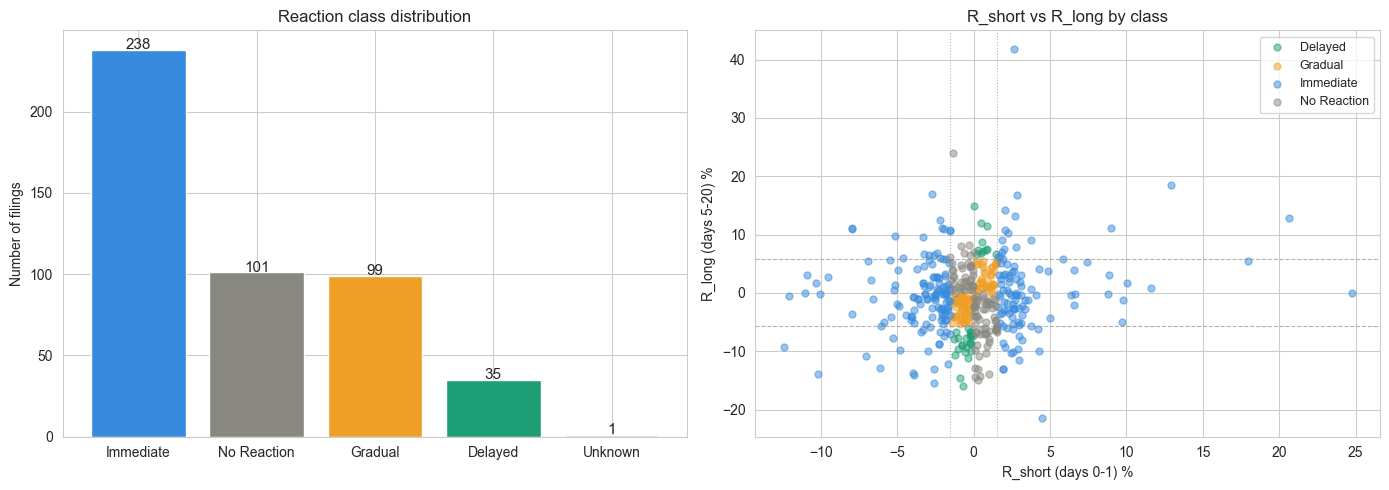

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Delayed':'#1D9E75','Gradual':'#EF9F27','Immediate':'#378ADD','No Reaction':'#888780','Unknown':'#D3D1C7'}

vc_plot = df['reaction_class'].value_counts()
ax = axes[0]
bars = ax.bar(vc_plot.index, vc_plot.values,
              color=[colors.get(c,'#888') for c in vc_plot.index], edgecolor='white')
ax.set_title('Reaction class distribution')
ax.set_ylabel('Number of filings')
for bar, val in zip(bars, vc_plot.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val), ha='center', fontsize=11)

ax2 = axes[1]
for cls, grp in df[df['reaction_class']!='Unknown'].groupby('reaction_class'):
    ax2.scatter(grp['R_short_0_1']*100, grp['R_long_5_20']*100,
                label=cls, alpha=0.5, s=25, color=colors.get(cls,'#888'))
ax2.axhline(long_threshold*100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.axhline(-long_threshold*100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.axvline(short_threshold*100, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax2.axvline(-short_threshold*100, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax2.set_xlabel('R_short (days 0-1) %')
ax2.set_ylabel('R_long (days 5-20) %')
ax2.set_title('R_short vs R_long by class')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Step 3 — C1: MOS Retrospective

Combines three signals into a single Missed Opportunity Score for ranking all 474 historical filings.

```
MOS = 0.4 x llm_importance_normalized
    + 0.2 x baseline_importance
    + 0.4 x reaction_pattern_score
```

**Weight rationale:** 60% on information content (LLM + text features), 40% on market pattern.
Judge answer: 'We want filings that are both important AND delayed — the two dimensions split 60/40.'

In [11]:
# Normalise LLM importance score 1-5 -> 0-1
df['llm_importance_norm'] = (df['importance_score'] - 1) / 4
median_imp = df['llm_importance_norm'].median()
df['llm_importance_norm'] = df['llm_importance_norm'].fillna(median_imp)
df['baseline_importance'] = df['baseline_importance'].fillna(df['baseline_importance'].median())

print(f'llm_importance_norm  mean={df["llm_importance_norm"].mean():.3f}')
print(f'baseline_importance  mean={df["baseline_importance"].mean():.3f}')
print(f'reaction_pattern_score mean={df["reaction_pattern_score"].mean():.3f}')

llm_importance_norm  mean=0.641
baseline_importance  mean=0.501
reaction_pattern_score mean=0.371


In [12]:
W_LLM      = 0.4
W_BASELINE = 0.2
W_REACTION = 0.4

df['MOS_retrospective'] = (
    W_LLM      * df['llm_importance_norm'] +
    W_BASELINE * df['baseline_importance'] +
    W_REACTION * df['reaction_pattern_score']
)

print(f'MOS_retrospective: min={df["MOS_retrospective"].min():.3f}  max={df["MOS_retrospective"].max():.3f}  mean={df["MOS_retrospective"].mean():.3f}')
print(df['MOS_retrospective'].describe().round(3).to_string())

MOS_retrospective: min=0.121  max=0.962  mean=0.505
count    474.000
mean       0.505
std        0.137
min        0.121
25%        0.416
50%        0.500
75%        0.587
max        0.962


In [13]:
WATCHLIST_COLS = [
    'ticker','filed_date','company_name','broad_category',
    'reaction_class','MOS_retrospective',
    'llm_importance_norm','baseline_importance','reaction_pattern_score',
    'importance_score','R_short_0_1','R_long_5_20',
    'reasoning','key_signals',
]
existing_w = [c for c in WATCHLIST_COLS if c in df.columns]

watchlist = (
    df[df['reaction_class'] != 'Unknown']
    .nlargest(30, 'MOS_retrospective')[existing_w]
    .reset_index(drop=True)
)
watchlist.index += 1

watchlist.to_csv(WATCHLIST_CSV, index=True, index_label='rank')
print(f'Top-30 watchlist saved: {WATCHLIST_CSV}')

show_cols = ['ticker','filed_date','broad_category','reaction_class','MOS_retrospective','importance_score','R_long_5_20']
display(watchlist[[c for c in show_cols if c in watchlist.columns]].head(10).round(3))

Top-30 watchlist saved: /Users/dagur/msba/bigdata/not-yet-priced-in/data/watchlist_final.csv


,ticker,filed_date,broad_category,reaction_class,MOS_retrospective,importance_score,R_long_5_20
1,BA,2023-12-11,Executive Change,Delayed,0.962,5.0,-0.160
2,COST,2023-11-24,Executive Change,Delayed,0.948,5.0,0.087
3,MSFT,2023-01-18,Regulatory,Delayed,0.914,5.0,0.073
4,JNJ,2023-10-17,Earnings,Delayed,0.897,5.0,-0.075
5,MSFT,2023-10-13,Acquisition/Disposition,Delayed,0.878,5.0,0.074
6,CVS,2023-10-13,Regulatory,Delayed,0.872,4.0,-0.061
7,CVS,2023-02-21,Regulatory,Delayed,0.861,4.0,-0.107
8,MRK,2023-05-17,Regulatory,Delayed,0.856,4.0,-0.100
9,T,2023-04-20,Regulatory,Delayed,0.841,4.0,-0.090
10,ABBV,2023-04-05,Earnings,Delayed,0.836,4.0,-0.088


In [14]:
print('Watchlist breakdown:')
print('By ticker:')
print(watchlist['ticker'].value_counts().head(10).to_string())
print('\nBy event category:')
print(watchlist['broad_category'].value_counts().to_string())
print('\nBy reaction class:')
print(watchlist['reaction_class'].value_counts().to_string())

Watchlist breakdown:
By ticker:
ticker
ABBV    4
AXP     4
MSFT    3
T       3
COST    2
JNJ     2
CVS     2
UNP     2
BA      1
MRK     1

By event category:
broad_category
Regulatory                 15
Executive Change            5
Earnings                    3
Material Agreement          3
Acquisition/Disposition     1
Financial Obligation        1
Voting Results              1
Other                       1

By reaction class:
reaction_class
Delayed    22
Gradual     8


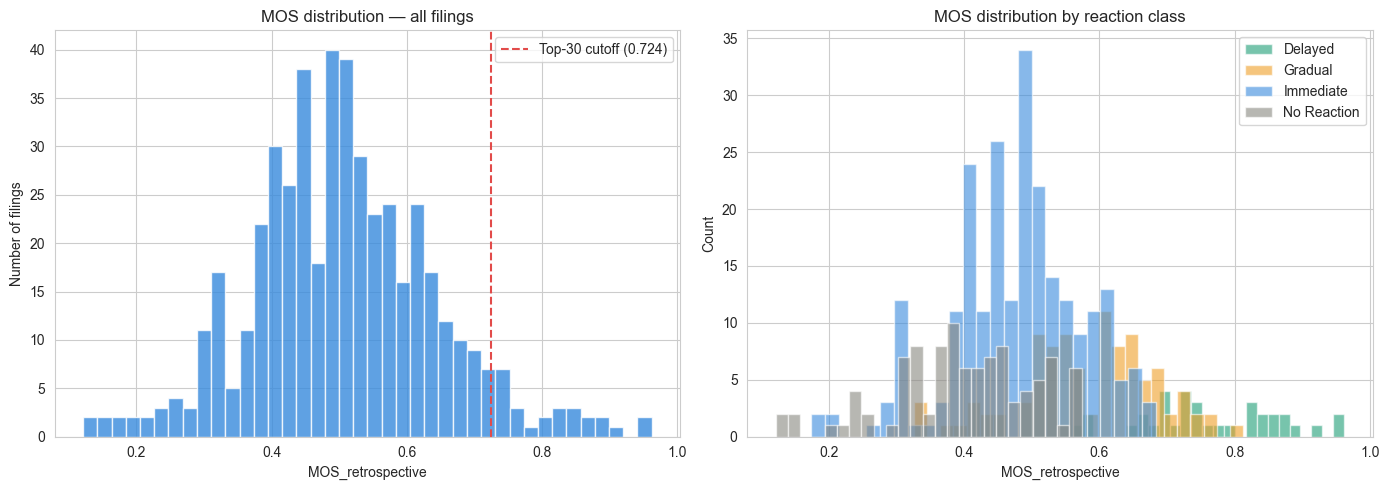

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['MOS_retrospective'], bins=40, edgecolor='white', color='#378ADD', alpha=0.8)
cutoff = watchlist['MOS_retrospective'].min()
ax.axvline(cutoff, color='#E24B4A', linestyle='--', label=f'Top-30 cutoff ({cutoff:.3f})')
ax.set_xlabel('MOS_retrospective')
ax.set_ylabel('Number of filings')
ax.set_title('MOS distribution — all filings')
ax.legend()

ax2 = axes[1]
colors2 = {'Delayed':'#1D9E75','Gradual':'#EF9F27','Immediate':'#378ADD','No Reaction':'#888780'}
for cls, grp in df[df['reaction_class']!='Unknown'].groupby('reaction_class'):
    ax2.hist(grp['MOS_retrospective'], bins=25, alpha=0.6, label=cls, color=colors2.get(cls,'#888'))
ax2.set_xlabel('MOS_retrospective')
ax2.set_ylabel('Count')
ax2.set_title('MOS distribution by reaction class')
ax2.legend()

plt.tight_layout()
plt.show()

---
## Step 4 — C2: Calibration Table

Descriptive frequency table comparing **Delayed** vs **non-Delayed** filings.

For each feature, computes:
```
lift = P(feature | Delayed) / P(feature | non-Delayed)
```

**This is not ML.** No training, no optimisation — just `pandas groupby().mean()`.
Includes bootstrap 95% confidence intervals and sample sizes.

Honest caveat for judges: *'Based on N=474 filings over 12 months; descriptive of 2023 patterns.'

In [17]:
calc_df = df[df['reaction_class'] != 'Unknown'].copy()
delayed_mask     = calc_df['reaction_class'] == 'Delayed'
non_delayed_mask = ~delayed_mask
n_delayed     = delayed_mask.sum()
n_non_delayed = non_delayed_mask.sum()
print(f'Delayed group    : {n_delayed}')
print(f'Non-Delayed group: {n_non_delayed}')

def safe_tier(series, labels=('low', 'mid', 'high')):
    """
    Assigns tercile tiers robustly.
    Falls back to fewer bins if duplicates prevent 3 distinct edges,
    and falls back to a single 'mid' tier if the column is constant.
    """
    s = series.fillna(0)
    n_unique = s.nunique()

    if n_unique >= 3:
        try:
            return pd.qcut(s, q=3, labels=labels, duplicates='drop')
        except ValueError:
            pass

    if n_unique == 2:
        # Only two distinct values — use median as split
        med = s.median()
        return pd.cut(s, bins=[-np.inf, med, np.inf],
                      labels=['low', 'high'], right=True)

    # Constant column — assign everything to 'mid'
    return pd.Categorical(['mid'] * len(s), categories=labels)


for feat in ['numeric_density', 'forward_looking_density', 'financial_symbol_density',
             'baseline_importance', 'llm_importance_norm']:
    if feat in calc_df.columns:
        calc_df[f'{feat}_tier'] = safe_tier(calc_df[feat])
        counts = calc_df[f'{feat}_tier'].value_counts().sort_index()
        print(f'  {feat}_tier: {dict(counts)}')

print('Tercile tiers created')

Delayed group    : 35
Non-Delayed group: 438
  numeric_density_tier: {'low': np.int64(158), 'mid': np.int64(158), 'high': np.int64(157)}
  forward_looking_density_tier: {'low': np.int64(0), 'mid': np.int64(473), 'high': np.int64(0)}
  financial_symbol_density_tier: {'low': np.int64(0), 'mid': np.int64(473), 'high': np.int64(0)}
  baseline_importance_tier: {'low': np.int64(158), 'mid': np.int64(157), 'high': np.int64(158)}
  llm_importance_norm_tier: {'low': np.int64(214), 'mid': np.int64(191), 'high': np.int64(68)}
Tercile tiers created


In [18]:
def compute_lift_row(feature_name, feature_value, delayed_mask, non_delayed_mask,
                     calc_df, n_delayed, n_non_delayed, n_bootstrap=500):
    col = calc_df[feature_name]
    in_d  = ((col == feature_value) & delayed_mask).sum()
    in_nd = ((col == feature_value) & non_delayed_mask).sum()
    p_d  = in_d  / n_delayed     if n_delayed     > 0 else 0
    p_nd = in_nd / n_non_delayed if n_non_delayed  > 0 else 0
    lift = p_d / p_nd if p_nd > 0 else np.nan

    # Bootstrap CI
    lifts_boot = []
    idx_d  = np.where(delayed_mask.values)[0]
    idx_nd = np.where(non_delayed_mask.values)[0]
    col_v  = col.values
    for _ in range(n_bootstrap):
        bd  = col_v[np.random.choice(idx_d,  size=len(idx_d),  replace=True)]
        bnd = col_v[np.random.choice(idx_nd, size=len(idx_nd), replace=True)]
        pd_ = (bd  == feature_value).mean()
        pnd = (bnd == feature_value).mean()
        lifts_boot.append(pd_ / pnd if pnd > 0 else np.nan)
    ci_lo = np.nanpercentile(lifts_boot, 2.5)
    ci_hi = np.nanpercentile(lifts_boot, 97.5)

    note = 'Strong' if lift >= 1.7 else 'Moderate' if lift >= 1.3 else 'Anti-signal' if lift <= 0.5 else ''
    return {
        'feature': feature_name, 'value': str(feature_value),
        'n_delayed': int(in_d), 'n_non_delayed': int(in_nd),
        'pct_delayed': round(p_d*100, 1), 'pct_non_delayed': round(p_nd*100, 1),
        'lift': round(lift, 2) if not np.isnan(lift) else None,
        'ci_95_lo': round(ci_lo, 2) if not np.isnan(ci_lo) else None,
        'ci_95_hi': round(ci_hi, 2) if not np.isnan(ci_hi) else None,
        'note': note,
    }

print('compute_lift_row() defined')

compute_lift_row() defined


In [19]:
print('Building calibration table (bootstrap CIs, ~30 sec)...')

calib_rows = []

# Broad event category
if 'broad_category' in calc_df.columns:
    for val in calc_df['broad_category'].dropna().unique():
        calib_rows.append(compute_lift_row('broad_category', val, delayed_mask, non_delayed_mask, calc_df, n_delayed, n_non_delayed))

# Tier features
tier_feature_map = [
    ('llm_importance_norm_tier',      'llm_importance_tier'),
    ('forward_looking_density_tier',  'forward_looking_tier'),
    ('numeric_density_tier',          'numeric_density_tier'),
    ('baseline_importance_tier',      'baseline_importance_tier'),
]
for col_name, display_name in tier_feature_map:
    if col_name in calc_df.columns:
        for val in ['low','mid','high']:
            row = compute_lift_row(col_name, val, delayed_mask, non_delayed_mask, calc_df, n_delayed, n_non_delayed)
            row['feature'] = display_name
            calib_rows.append(row)

calibration_table = pd.DataFrame(calib_rows).sort_values('lift', ascending=False)
calibration_table.to_csv(CALIBRATION_CSV, index=False)
print(f'Calibration table saved: {CALIBRATION_CSV}')
print(f'Rows: {len(calibration_table)}')

Building calibration table (bootstrap CIs, ~30 sec)...
Calibration table saved: /Users/dagur/msba/bigdata/not-yet-priced-in/data/calibration_table.csv
Rows: 21


In [20]:
print('=' * 72)
print(f'  CALIBRATION TABLE  (n_delayed={n_delayed}, n_non_delayed={n_non_delayed})')
print(f'  Descriptive of 2023 patterns — not a predictive claim')
print('=' * 72)

display_cols = ['feature','value','pct_delayed','pct_non_delayed','lift','ci_95_lo','ci_95_hi','note']
display(calibration_table[display_cols].reset_index(drop=True))

print('\nStrong signals (lift >= 1.7):')
strong = calibration_table[calibration_table['lift'] >= 1.7]
for _, r in strong.iterrows():
    print(f'  {r["feature"]} = {r["value"]:<20}  lift={r["lift"]}x  ({r["pct_delayed"]}% vs {r["pct_non_delayed"]}%)')

  CALIBRATION TABLE  (n_delayed=35, n_non_delayed=438)
  Descriptive of 2023 patterns — not a predictive claim


,feature,value,pct_delayed,pct_non_delayed,lift,ci_95_lo,ci_95_hi,note
0,broad_category,Acquisition/Disposition,2.9,0.5,6.26,0.00,25.03,Strong
1,broad_category,Governance,8.6,2.5,3.41,0.00,9.39,Strong
2,baseline_importance_tier,high,51.4,32.0,1.61,1.04,2.22,Moderate
3,broad_category,Regulatory,40.0,26.7,1.50,0.90,2.25,Moderate
4,broad_category,Executive Change,20.0,14.8,1.35,0.57,2.42,Moderate
5,numeric_density_tier,low,42.9,32.6,1.31,0.85,1.89,Moderate
6,llm_importance_tier,low,54.3,44.5,1.22,0.82,1.58,
7,numeric_density_tier,high,37.1,32.9,1.13,0.64,1.63,
8,forward_looking_tier,mid,100.0,100.0,1.00,1.00,1.00,
9,llm_importance_tier,high,14.3,14.4,0.99,0.35,2.01,



Strong signals (lift >= 1.7):
  broad_category = Acquisition/Disposition  lift=6.26x  (2.9% vs 0.5%)
  broad_category = Governance            lift=3.41x  (8.6% vs 2.5%)


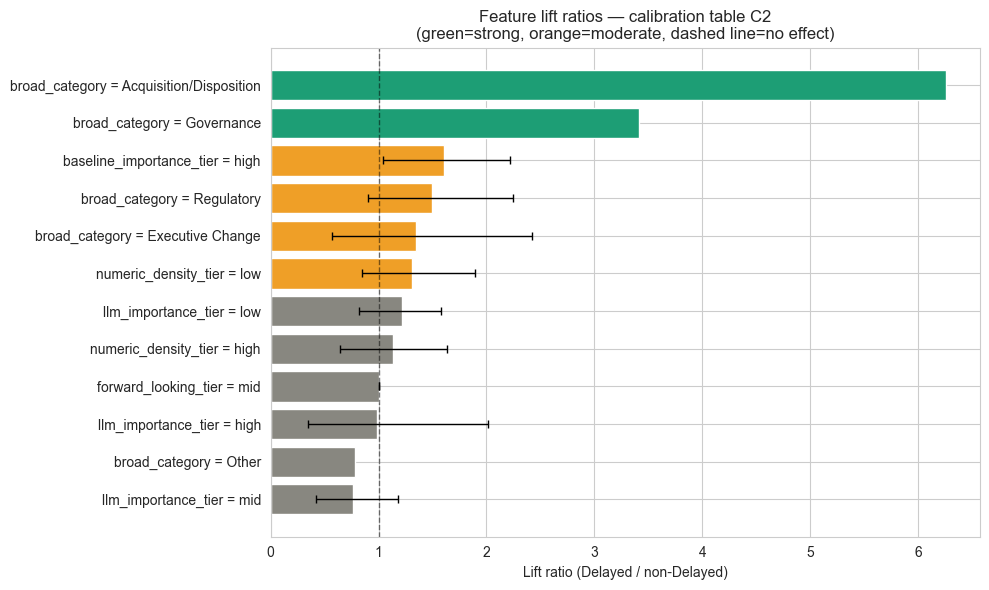

In [21]:
top_lift = calibration_table.dropna(subset=['lift']).head(12).copy()
top_lift['label'] = top_lift['feature'] + ' = ' + top_lift['value'].astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#1D9E75' if l >= 1.7 else '#EF9F27' if l >= 1.3 else '#888780' for l in top_lift['lift']]
ax.barh(top_lift['label'], top_lift['lift'], color=bar_colors, edgecolor='white')
ax.axvline(1.0, color='black', linewidth=1, linestyle='--', alpha=0.5)

for i, (_, row) in enumerate(top_lift.iterrows()):
    if row['ci_95_lo'] and row['ci_95_hi']:
        ax.errorbar(row['lift'], i,
                    xerr=[[row['lift']-row['ci_95_lo']],[row['ci_95_hi']-row['lift']]],
                    fmt='none', color='black', capsize=3, linewidth=1)

ax.set_xlabel('Lift ratio (Delayed / non-Delayed)')
ax.set_title('Feature lift ratios — calibration table C2\n(green=strong, orange=moderate, dashed line=no effect)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Step 5 — C3: MOS Prospective

A lookup function that scores a **brand-new filing** using the C2 lift ratios.
No market reaction data needed — only the filing's text features.

**Interpretation:** MOS_prospective = 0.80 means this filing's feature profile
matches the top 20% of historical Delayed-reaction filings.

**Framing for judges:** 'This is a prior probability based on 2023 patterns — decision support, not prediction.'

In [22]:
def build_lift_lookup(calibration_table):
    lookup = {}
    for _, row in calibration_table.iterrows():
        feat = row['feature']
        val  = str(row['value'])
        lift = row['lift'] if row['lift'] and not pd.isna(row['lift']) else 1.0
        if feat not in lookup:
            lookup[feat] = {}
        lookup[feat][val] = lift
    return lookup

lift_lookup = build_lift_lookup(calibration_table)

print('Lift lookup built. Features:')
for feat, vals in lift_lookup.items():
    print(f'  {feat}: {list(vals.keys())}')

Lift lookup built. Features:
  broad_category: ['Acquisition/Disposition', 'Governance', 'Regulatory', 'Executive Change', 'Other', 'Voting Results', 'Earnings', 'Financial Obligation', 'Material Agreement']
  baseline_importance_tier: ['high', 'low', 'mid']
  numeric_density_tier: ['low', 'high', 'mid']
  llm_importance_tier: ['low', 'high', 'mid']
  forward_looking_tier: ['mid', 'low', 'high']


In [23]:
# Compute tier thresholds from corpus
tier_thresholds = {}
for feat_col, feat_name in [
    ('forward_looking_density', 'forward_looking_tier'),
    ('numeric_density',         'numeric_density_tier'),
    ('baseline_importance',     'baseline_importance_tier'),
    ('llm_importance_norm',     'llm_importance_tier'),
]:
    if feat_col in calc_df.columns:
        lo = calc_df[feat_col].quantile(0.33)
        hi = calc_df[feat_col].quantile(0.67)
        tier_thresholds[feat_name] = (lo, hi)
        print(f'  {feat_name}: low<{lo:.3f}, high>{hi:.3f}')

print('Tier thresholds ready')

  forward_looking_tier: low<0.000, high>1.234
  numeric_density_tier: low<6.476, high>10.256
  baseline_importance_tier: low<0.414, high>0.582
  llm_importance_tier: low<0.500, high>0.750
Tier thresholds ready


In [24]:
def get_tier(value, thresholds):
    if pd.isna(value): return 'mid'
    lo, hi = thresholds
    if value <= lo:  return 'low'
    if value >= hi:  return 'high'
    return 'mid'


def MOS_prospective(filing_dict, lift_lookup, tier_thresholds, all_prior_scores=None):
    prior = 1.0
    components = {}

    # 1. Event category
    broad_cat = str(filing_dict.get('broad_category', 'Other'))
    l = lift_lookup.get('broad_category', {}).get(broad_cat, 1.0)
    prior *= l; components['broad_category_lift'] = l

    # 2. LLM importance tier
    imp = filing_dict.get('importance_score', 3)
    imp_norm = (imp - 1) / 4 if imp else 0.5
    tier = get_tier(imp_norm, tier_thresholds.get('llm_importance_tier', (0.33, 0.67)))
    l = lift_lookup.get('llm_importance_tier', {}).get(tier, 1.0)
    prior *= l; components['llm_importance_lift'] = l

    # 3. Forward-looking density tier
    fld = filing_dict.get('forward_looking_density', 0)
    tier = get_tier(fld, tier_thresholds.get('forward_looking_tier', (0, 0)))
    l = lift_lookup.get('forward_looking_tier', {}).get(tier, 1.0)
    prior *= l; components['forward_looking_lift'] = l

    # 4. Numeric density tier
    nd = filing_dict.get('numeric_density', 0)
    tier = get_tier(nd, tier_thresholds.get('numeric_density_tier', (0, 0)))
    l = lift_lookup.get('numeric_density_tier', {}).get(tier, 1.0)
    prior *= l; components['numeric_density_lift'] = l

    # 5. Baseline importance tier
    bi = filing_dict.get('baseline_importance', 0.5)
    tier = get_tier(bi, tier_thresholds.get('baseline_importance_tier', (0.33, 0.67)))
    l = lift_lookup.get('baseline_importance_tier', {}).get(tier, 1.0)
    prior *= l; components['baseline_importance_lift'] = l

    # Normalise to 0-1 rank within corpus
    rank_pct = float((prior > np.array(all_prior_scores)).mean()) if all_prior_scores is not None else None

    interp = f'Feature profile matches top {(1-rank_pct)*100:.0f}% of historical Delayed filings' \
             if rank_pct is not None else 'No normalisation'

    return {
        'prior_score':     round(prior, 4),
        'MOS_prospective': round(rank_pct, 3) if rank_pct is not None else None,
        'components':      components,
        'interpretation':  interp,
    }

print('MOS_prospective() defined')

MOS_prospective() defined


In [25]:
# Compute prior scores for all historical filings (needed for normalisation)
prior_scores_all = []
for _, row in calc_df.iterrows():
    r = MOS_prospective(row.to_dict(), lift_lookup, tier_thresholds)
    prior_scores_all.append(r['prior_score'])

# Re-run with normalisation
mos_p_list = []
for _, row in calc_df.iterrows():
    r = MOS_prospective(row.to_dict(), lift_lookup, tier_thresholds, all_prior_scores=prior_scores_all)
    mos_p_list.append(r['MOS_prospective'])

calc_df['MOS_prospective'] = mos_p_list
df = df.join(calc_df[['MOS_prospective']], how='left')

print(f'MOS_prospective computed for {calc_df["MOS_prospective"].notna().sum()} filings')
print(f'Mean: {calc_df["MOS_prospective"].mean():.3f}  Std: {calc_df["MOS_prospective"].std():.3f}')

MOS_prospective computed for 473 filings
Mean: 0.492  Std: 0.291


In [26]:
# Test: score a hypothetical new filing
test_filing = {
    'broad_category':           'Executive Change',
    'importance_score':          4,
    'forward_looking_density':   5.2,
    'numeric_density':           7.8,
    'baseline_importance':       0.72,
}
result = MOS_prospective(test_filing, lift_lookup, tier_thresholds, all_prior_scores=prior_scores_all)
print('Hypothetical new filing:')
print(f'  prior_score     : {result["prior_score"]}')
print(f'  MOS_prospective : {result["MOS_prospective"]}')
print(f'  Interpretation  : {result["interpretation"]}')
print('  Component lifts:')
for k, v in result['components'].items():
    print(f'    {k:<30}: {v:.3f}x')

Hypothetical new filing:
  prior_score     : 1.248
  MOS_prospective : 0.562
  Interpretation  : Feature profile matches top 44% of historical Delayed filings
  Component lifts:
    broad_category_lift           : 1.350x
    llm_importance_lift           : 0.990x
    forward_looking_lift          : 1.000x
    numeric_density_lift          : 0.580x
    baseline_importance_lift      : 1.610x


---
## Step 6 — December Live Replay

Simulates using MOS_prospective on December 2023 filings **as if seeing them for the first time**,
then reveals what the market actually did.

Frame this in the demo as: *'Here is the mechanism — not an accuracy test.'

In [27]:
if 'filed_date' in df.columns:
    df['filed_date_dt'] = pd.to_datetime(df['filed_date'], errors='coerce')
    dec_mask = (df['filed_date_dt'].dt.month == 12) & (df['filed_date_dt'].dt.year == 2023)
    dec_filings = df[dec_mask].copy()
    print(f'December 2023 filings found: {len(dec_filings)}')
else:
    print('filed_date column not found')
    dec_filings = pd.DataFrame()

December 2023 filings found: 24


In [28]:
if len(dec_filings) > 0:
    dec_results = []
    for _, row in dec_filings.iterrows():
        result = MOS_prospective(row.to_dict(), lift_lookup, tier_thresholds, all_prior_scores=prior_scores_all)
        dec_results.append({
            'ticker':           row.get('ticker',''),
            'filed_date':       row.get('filed_date',''),
            'broad_category':   row.get('broad_category',''),
            'importance_score': row.get('importance_score',''),
            'MOS_prospective':  result['MOS_prospective'],
            'R_short_0_1':      row.get('R_short_0_1', None),
            'R_long_5_20':      row.get('R_long_5_20', None),
            'reaction_class':   row.get('reaction_class', 'Unknown'),
        })

    dec_df = pd.DataFrame(dec_results).sort_values('MOS_prospective', ascending=False)

    print('December filings ranked by MOS_prospective (what the system would have flagged):')
    display(dec_df[['ticker','filed_date','broad_category','importance_score',
                    'MOS_prospective','R_long_5_20','reaction_class']].head(10).round(3))

    print('\nTop 5 flagged — actual market outcome:')
    for _, r in dec_df.head(5).iterrows():
        rxn   = r['reaction_class'] if r['reaction_class'] != 'Unknown' else 'no data'
        rlong = f"{r['R_long_5_20']*100:.2f}%" if pd.notna(r['R_long_5_20']) else 'n/a'
        print(f'  {r["ticker"]:<6} {r["filed_date"]}  MOS={r["MOS_prospective"]:.2f}  R_long={rlong}  class={rxn}')
else:
    print('No December filings found')

December filings ranked by MOS_prospective (what the system would have flagged):


,ticker,filed_date,broad_category,importance_score,MOS_prospective,R_long_5_20,reaction_class
20,PFE,2023-12-14,Acquisition/Disposition,5.0,0.994,-0.003,Immediate
11,INTC,2023-12-05,Governance,2.0,0.975,0.055,Gradual
3,AXP,2023-12-15,Regulatory,3.0,0.958,-0.034,Immediate
21,UNH,2023-12-29,Regulatory,5.0,0.930,NaN,Unknown
15,NFLX,2023-12-08,Executive Change,4.0,0.915,0.001,Gradual
4,BA,2023-12-11,Executive Change,5.0,0.837,-0.160,Delayed
16,NKE,2023-12-21,Financial Obligation,4.0,0.837,-0.094,Immediate
22,UNP,2023-12-14,Executive Change,3.0,0.759,-0.025,Gradual
14,MSFT,2023-12-08,Voting Results,3.0,0.670,0.019,No Reaction
23,XOM,2023-12-06,Regulatory,5.0,0.562,0.009,No Reaction



Top 5 flagged — actual market outcome:
  PFE    2023-12-14  MOS=0.99  R_long=-0.29%  class=Immediate
  INTC   2023-12-05  MOS=0.97  R_long=5.51%  class=Gradual
  AXP    2023-12-15  MOS=0.96  R_long=-3.37%  class=Immediate
  UNH    2023-12-29  MOS=0.93  R_long=n/a  class=no data
  NFLX   2023-12-08  MOS=0.92  R_long=0.12%  class=Gradual


---
## Step 7 — Save master_scored.csv

Single output file consumed by NB4 (validation) and NB5 (demo).

In [29]:
MASTER_COLS = [
    'filename','ticker','filed_date','company_name',
    'broad_category','llm_event_category','primary_item',
    'numeric_density','forward_looking_density','financial_symbol_density',
    'baseline_importance','importance_score','llm_importance_norm',
    'key_signals','reasoning','grounding_rate',
    'R_short_0_1','R_long_5_20','reaction_class','reaction_pattern_score',
    'MOS_retrospective','MOS_prospective',
    'clean_text',
]
existing_m = [c for c in MASTER_COLS if c in df.columns]
master = df[existing_m].copy()
master.to_csv(MASTER_CSV, index=False)
print(f'master_scored.csv saved: {len(master)} rows, {len(master.columns)} cols')
print(f'Path: {MASTER_CSV}')

master_scored.csv saved: 474 rows, 23 cols
Path: /Users/dagur/msba/bigdata/not-yet-priced-in/data/master_scored.csv


In [30]:
print('=' * 58)
print('  NB3 COMPLETE')
print('=' * 58)
print(f'  Total filings        : {len(df)}')
print(f'  With reaction data   : {(df["reaction_class"]!="Unknown").sum()}')
print(f'  Delayed class        : {(df["reaction_class"]=="Delayed").sum()}')
print(f'  Mean MOS_retro       : {df["MOS_retrospective"].mean():.3f}')
print()
print('  Outputs:')
print(f'    {REACTIONS_FULL_CSV}')
print(f'    {WATCHLIST_CSV}')
print(f'    {CALIBRATION_CSV}')
print(f'    {MASTER_CSV}')
print()
print('  Next steps:')
print('    1. Run NB4 (validation — D1/D2/D3/D4)')
print('    2. Fill a4_human_labels_template.csv for D2 (needs 2 people)')
print('    3. Pick 3-5 case studies from watchlist for NB5 demo')
print('=' * 58)

  NB3 COMPLETE
  Total filings        : 474
  With reaction data   : 473
  Delayed class        : 35
  Mean MOS_retro       : 0.505

  Outputs:
    /Users/dagur/msba/bigdata/not-yet-priced-in/data/reactions_full.csv
    /Users/dagur/msba/bigdata/not-yet-priced-in/data/watchlist_final.csv
    /Users/dagur/msba/bigdata/not-yet-priced-in/data/calibration_table.csv
    /Users/dagur/msba/bigdata/not-yet-priced-in/data/master_scored.csv

  Next steps:
    1. Run NB4 (validation — D1/D2/D3/D4)
    2. Fill a4_human_labels_template.csv for D2 (needs 2 people)
    3. Pick 3-5 case studies from watchlist for NB5 demo


---
## Appendix — Top watchlist case study preview

Quick look at the top 5 filings for NB5 case study selection.

In [31]:
if len(watchlist) > 0 and 'reasoning' in watchlist.columns:
    print('Top 5 watchlist — LLM reasoning + key signals\n')
    for rank, row in watchlist.head(5).iterrows():
        print(f'Rank {rank}. {row.get("ticker","")} — {row.get("filed_date","")}'
              f'  [{row.get("broad_category","")} / {row.get("reaction_class","")}]')
        print(f'  MOS: {row["MOS_retrospective"]:.3f}'
              f'  R_long: {row.get("R_long_5_20",0)*100:.2f}%'
              f'  LLM importance: {row.get("importance_score","")}')
        if pd.notna(row.get('reasoning','')):
            print(f'  Reasoning: {str(row["reasoning"])[:200]}')
        if pd.notna(row.get('key_signals','')):
            try:
                signals = json.loads(str(row['key_signals']))
                for s in signals[:2]:
                    print(f'    - {str(s)[:100]}')
            except Exception:
                print(f'    {str(row["key_signals"])[:150]}')
        print()

Top 5 watchlist — LLM reasoning + key signals

Rank 1. BA — 2023-12-11  [Executive Change / Delayed]
  MOS: 0.962  R_long: -16.00%  LLM importance: 5.0
  Reasoning: The filing announces a significant executive appointment with Stephanie F. Pope being elected as Executive Vice President and Chief Operating Officer. It includes her extensive history with the compan
    - the Board of Directors (the "Board") of The Boeing Company (the "Company") elected Stephanie F. Pope
    - effective January 1, 2024

Rank 2. COST — 2023-11-24  [Executive Change / Delayed]
  MOS: 0.948  R_long: 8.73%  LLM importance: 5.0
  Reasoning: The filing details a significant executive change with Ron Vachris assuming the roles of President and CEO, along with specific bonus structures approved for fiscal year 2024. The changes in leadershi
    - approved the fiscal 2024 criteria for bonuses to executive officers
    - Ron Vachris will serve as President until December 31, 2023

Rank 3. MSFT — 2023-01-18  [Regula